# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video.

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time.

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

ANS: The base architecture of YOLO includes a CNN applied to an image split into a grid. YOLO detects the bounding boxes for objects in the image and the probability of class of object found in the bounding box. What is special in YOLO as compared to other CNN-based detection algorithms is the loss function it uses. The loss function can be divided into object class loss and localization loss. The object class loss is a sum of the square difference of the probability of a given class in prediction vs ground truth summed over all classes and all grid cells in which there is an object. The localization loss is made up of the loss of the coordinates and sizes of the bounding boxes predicted and the confidence scores. All these losses are minimized together - this way the model can find the objects and classify them in the same CNN as opposed to finding the regions and then applying separate CNN to each region.
In YOLO v11 specifically there are some additions as compared with the earlier YOLO models which enhance its action. Specifically YOLO v11 is made of three main components: the backbone, the neck and the head. The backbone contains the CNN to extract features from the image and it also contains C2PSA (Convolutional block with Parallel Spatial Attention) which allows the network to learn which spatial regions matter most. The neck fuses the features generated in the backbone. Finally, the head takes the fused features and outputs the bounding boxes and class probabilities.

What are the metrics used to assess YOLO's performance for object detection?

ANS: The main metric is the mAP (mean average precision). It averages the precision accross the different Intersection/Union thresholds and classes. The most typical metrics are mAP50 and mAP50-95.
mAP50 is the mean average precision computed at IoU threshold of 50% (box is counted as correct if it overlaps with ground truth box by at least 50%). mAP50-95 averaged across IoU thresholds from 0.5 to 0.95 in 0.05 steps.
Other important metrics include recall and precision (we can also make precision recall curves). Recall measures how many of the true positives in the ground truth were identified by the model, while precision measures how many of the model guesses were correct.
We also care about speed of detection hence we might be interested in how many frames per second (FPS) the model can process.

## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [1]:
!pip install ultralytics opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00


In [4]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue  # Skip irrelevant classes

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)



Download complete.
Extracting /content/data_object_image_2.zip...
Extraction complete.
Download complete.
Extracting /content/data_object_label_2.zip...
Extraction complete.


In [23]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model
# ---------------------------------------------
#TO-DO: Add the code to fine-tune the YOLOv11 model

from ultralytics import YOLO

# using yolo 11 n model
model = YOLO("yolo11s.pt")


results = model.train(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    epochs=50,
    imgsz=1280,           # bigger resolution — helps pedestrians/cyclists
    batch=8,              # reduced from 16 to fit 1280px images on T4
    name="yolo11s_kitti_tuned",
    project=os.path.join(HOME, "runs"),
    device=0,
    workers=4,
    patience=20,          # more patience — small datasets plateau slowly
    save=True,
    plots=True,

    # --- optimizer ---
    optimizer="AdamW",    # more stable than default SGD on small datasets
    lr0=0.001,            # lower initial lr for AdamW
    lrf=0.01,             # cosine decay to lr0 * lrf = 0.00001
    cos_lr=True,          # smooth cosine schedule
    warmup_epochs=5,      # longer warmup on small data

    # augmentation
    hsv_h=0.015, # randomly shifts hue
    hsv_s=0.7,    # randomly changes color saturation
    hsv_v=0.4,    # randomly varies brightness
    fliplr=0.5,   # randomly mirrors image
    mosaic=1.0,   # combines 4 images into 1
    mixup=0.1,    # blends 2 images
    copy_paste=0.3, # cuts objects from one image into another
    degrees=5.0,          # small random rotation
    translate=0.1,        # random translation
    scale=0.5,            # random scale — helps small object detection

    # regularization
    dropout=0.1,          # prevent overfitting on small dataset
    weight_decay=0.0005,
)

# evaluating on test set
metrics = model.val(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    split="test",
)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/kitti_subset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_kitti_tuned-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap

Trainings summary:
- YOLOn - mAP50:0.4946
- YOLOn with augmentations - mAP50: 0.4817
- YOLOn with augmentations and regularization - mAP50: 0.6100
- YOLOs with augmentations - mAP50: 0.5129
- YOLOs with augmentations and regularization - mAP50:
- YOLOm with augmentations - mAP50: 0.6527


# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

In [12]:
import glob
glob.glob('/content/runs/**/results.csv', recursive=True)

['/content/runs/yolo11n_kitti/results.csv',
 '/content/runs/yolo11n_kitti-4/results.csv',
 '/content/runs/yolo11n_kitti-2/results.csv',
 '/content/runs/yolo11s_kitti_tuned/results.csv',
 '/content/runs/yolo11n_kitti-3/results.csv']

Using: /content/runs/yolo11s_kitti_tuned/results.csv


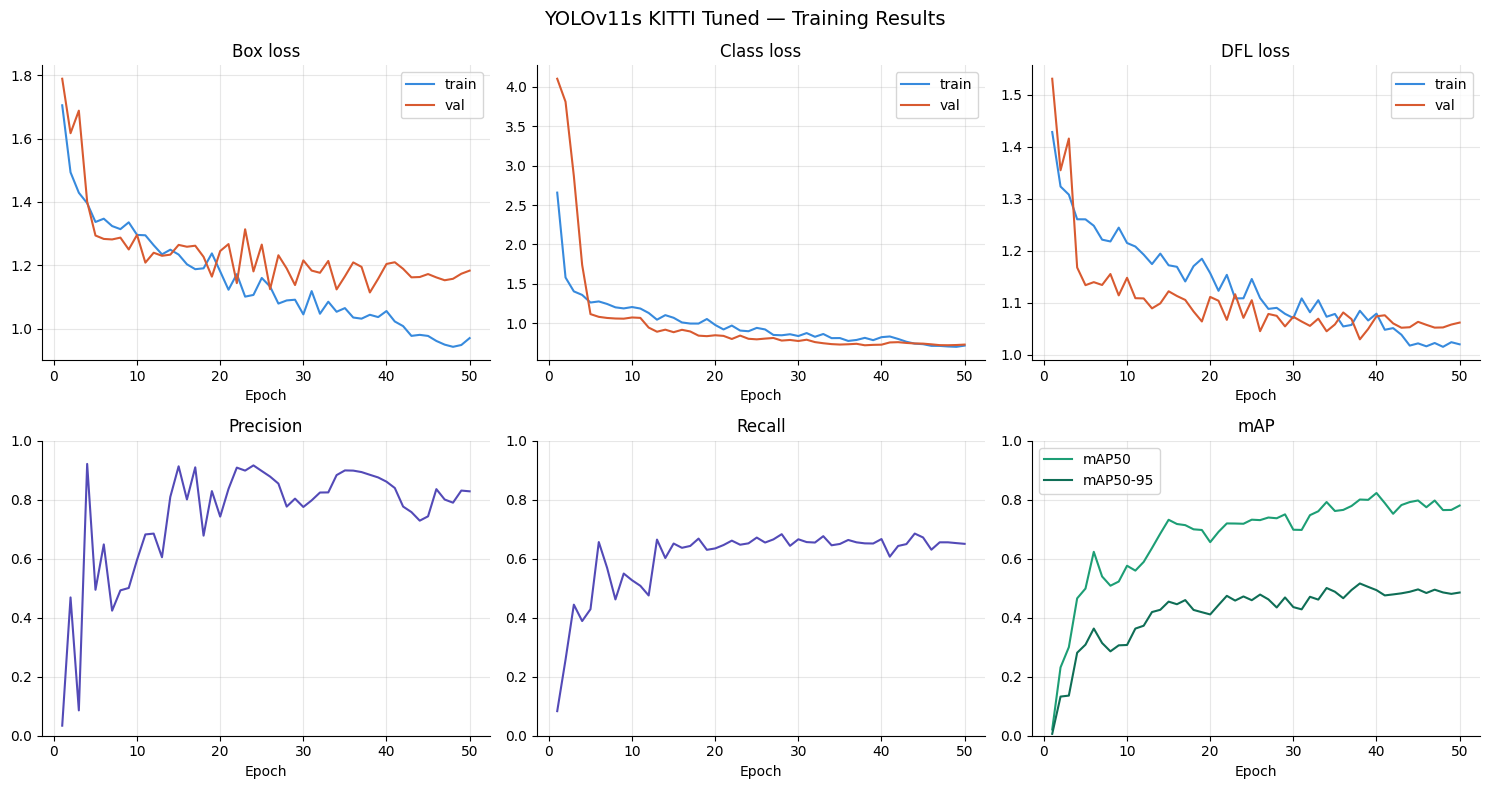

In [25]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
#TO-DO: Add the code to visualize the training losses and metrics

import pandas as pd
import matplotlib.pyplot as plt

results_path = sorted(glob.glob('/content/runs/**/results.csv', recursive=True))[-1]
print(f"Using: {results_path}")

df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('YOLOv11s KITTI Tuned — Training Results', fontsize=14)

# losses
axes[0,0].plot(df['epoch'], df['train/box_loss'], label='train', color='#378ADD')
axes[0,0].plot(df['epoch'], df['val/box_loss'],   label='val',   color='#D85A30')
axes[0,0].set_title('Box loss')
axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='train', color='#378ADD')
axes[0,1].plot(df['epoch'], df['val/cls_loss'],   label='val',   color='#D85A30')
axes[0,1].set_title('Class loss')
axes[0,1].legend()

axes[0,2].plot(df['epoch'], df['train/dfl_loss'], label='train', color='#378ADD')
axes[0,2].plot(df['epoch'], df['val/dfl_loss'],   label='val',   color='#D85A30')
axes[0,2].set_title('DFL loss')
axes[0,2].legend()

# metrics
axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], color='#534AB7')
axes[1,0].set_title('Precision')
axes[1,0].set_ylim(0, 1)

axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], color='#534AB7')
axes[1,1].set_title('Recall')
axes[1,1].set_ylim(0, 1)


axes[1,2].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP50',    color='#1D9E75')
axes[1,2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='#0F6E56')
axes[1,2].set_title('mAP')
axes[1,2].set_ylim(0, 1)
axes[1,2].legend()

for ax in axes.flat:
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Using: /content/runs/yolo11s_kitti_tuned/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3577.8±1377.3 MB/s, size: 851.2 KB)
val: Scanning /content/datasets/kitti_subset/labels/test.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 6.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0it/s 1.9s
                   all         30        159      0.585      0.668       0.61       0.36
                   Car         27        121      0.815      0.926      0.943      0.656
            Pedestrian          9         28      0.465      0.679      0.606      0.321
               Cyclist          6         10      0.477        0.4      0.281      0.104
Speed: 13.9ms preprocess, 6.7ms inference, 0.0ms loss, 4.1ms postproc

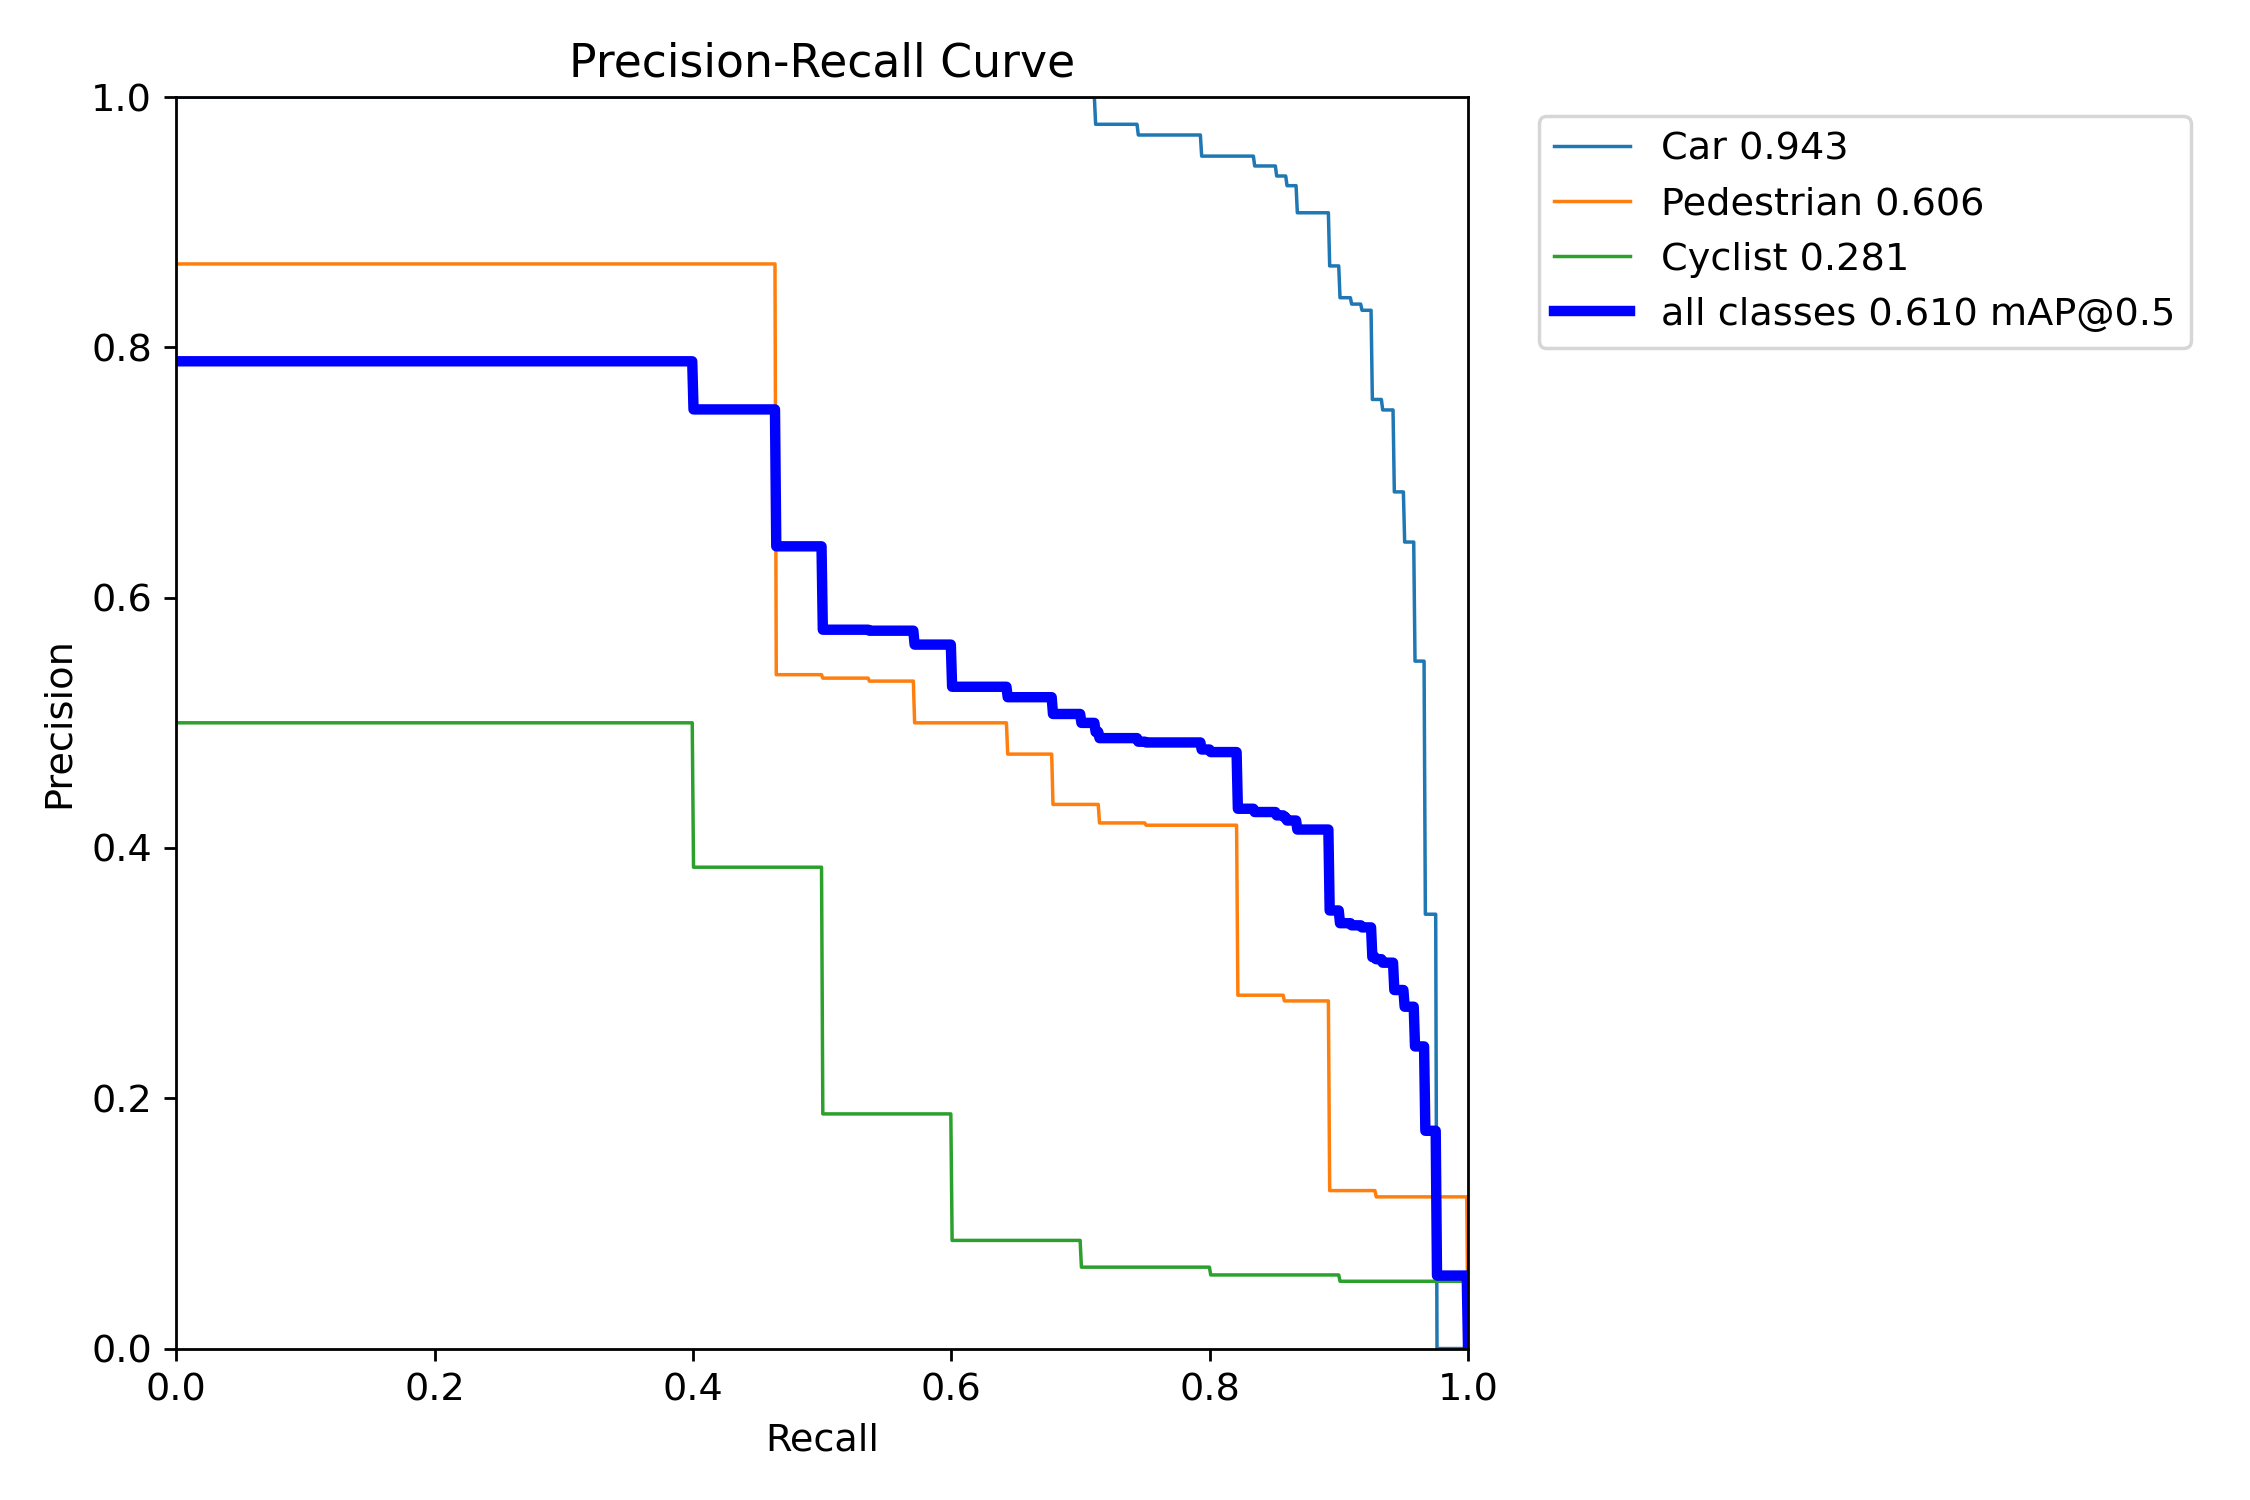

In [26]:
#plotting precision vs recall

import glob

latest_weights = sorted(glob.glob('/content/runs/**/best.pt', recursive=True))[-1]
print(f"Using: {latest_weights}")

model = YOLO(latest_weights)

metrics = model.val(
    data=os.path.join(DATASET_PATH, "data.yaml"),
    split='test',
    plots=True,
)
from IPython.display import Image
Image('/content/runs/detect/val-8/BoxPR_curve.png')

Confusion Matrix (normalized)


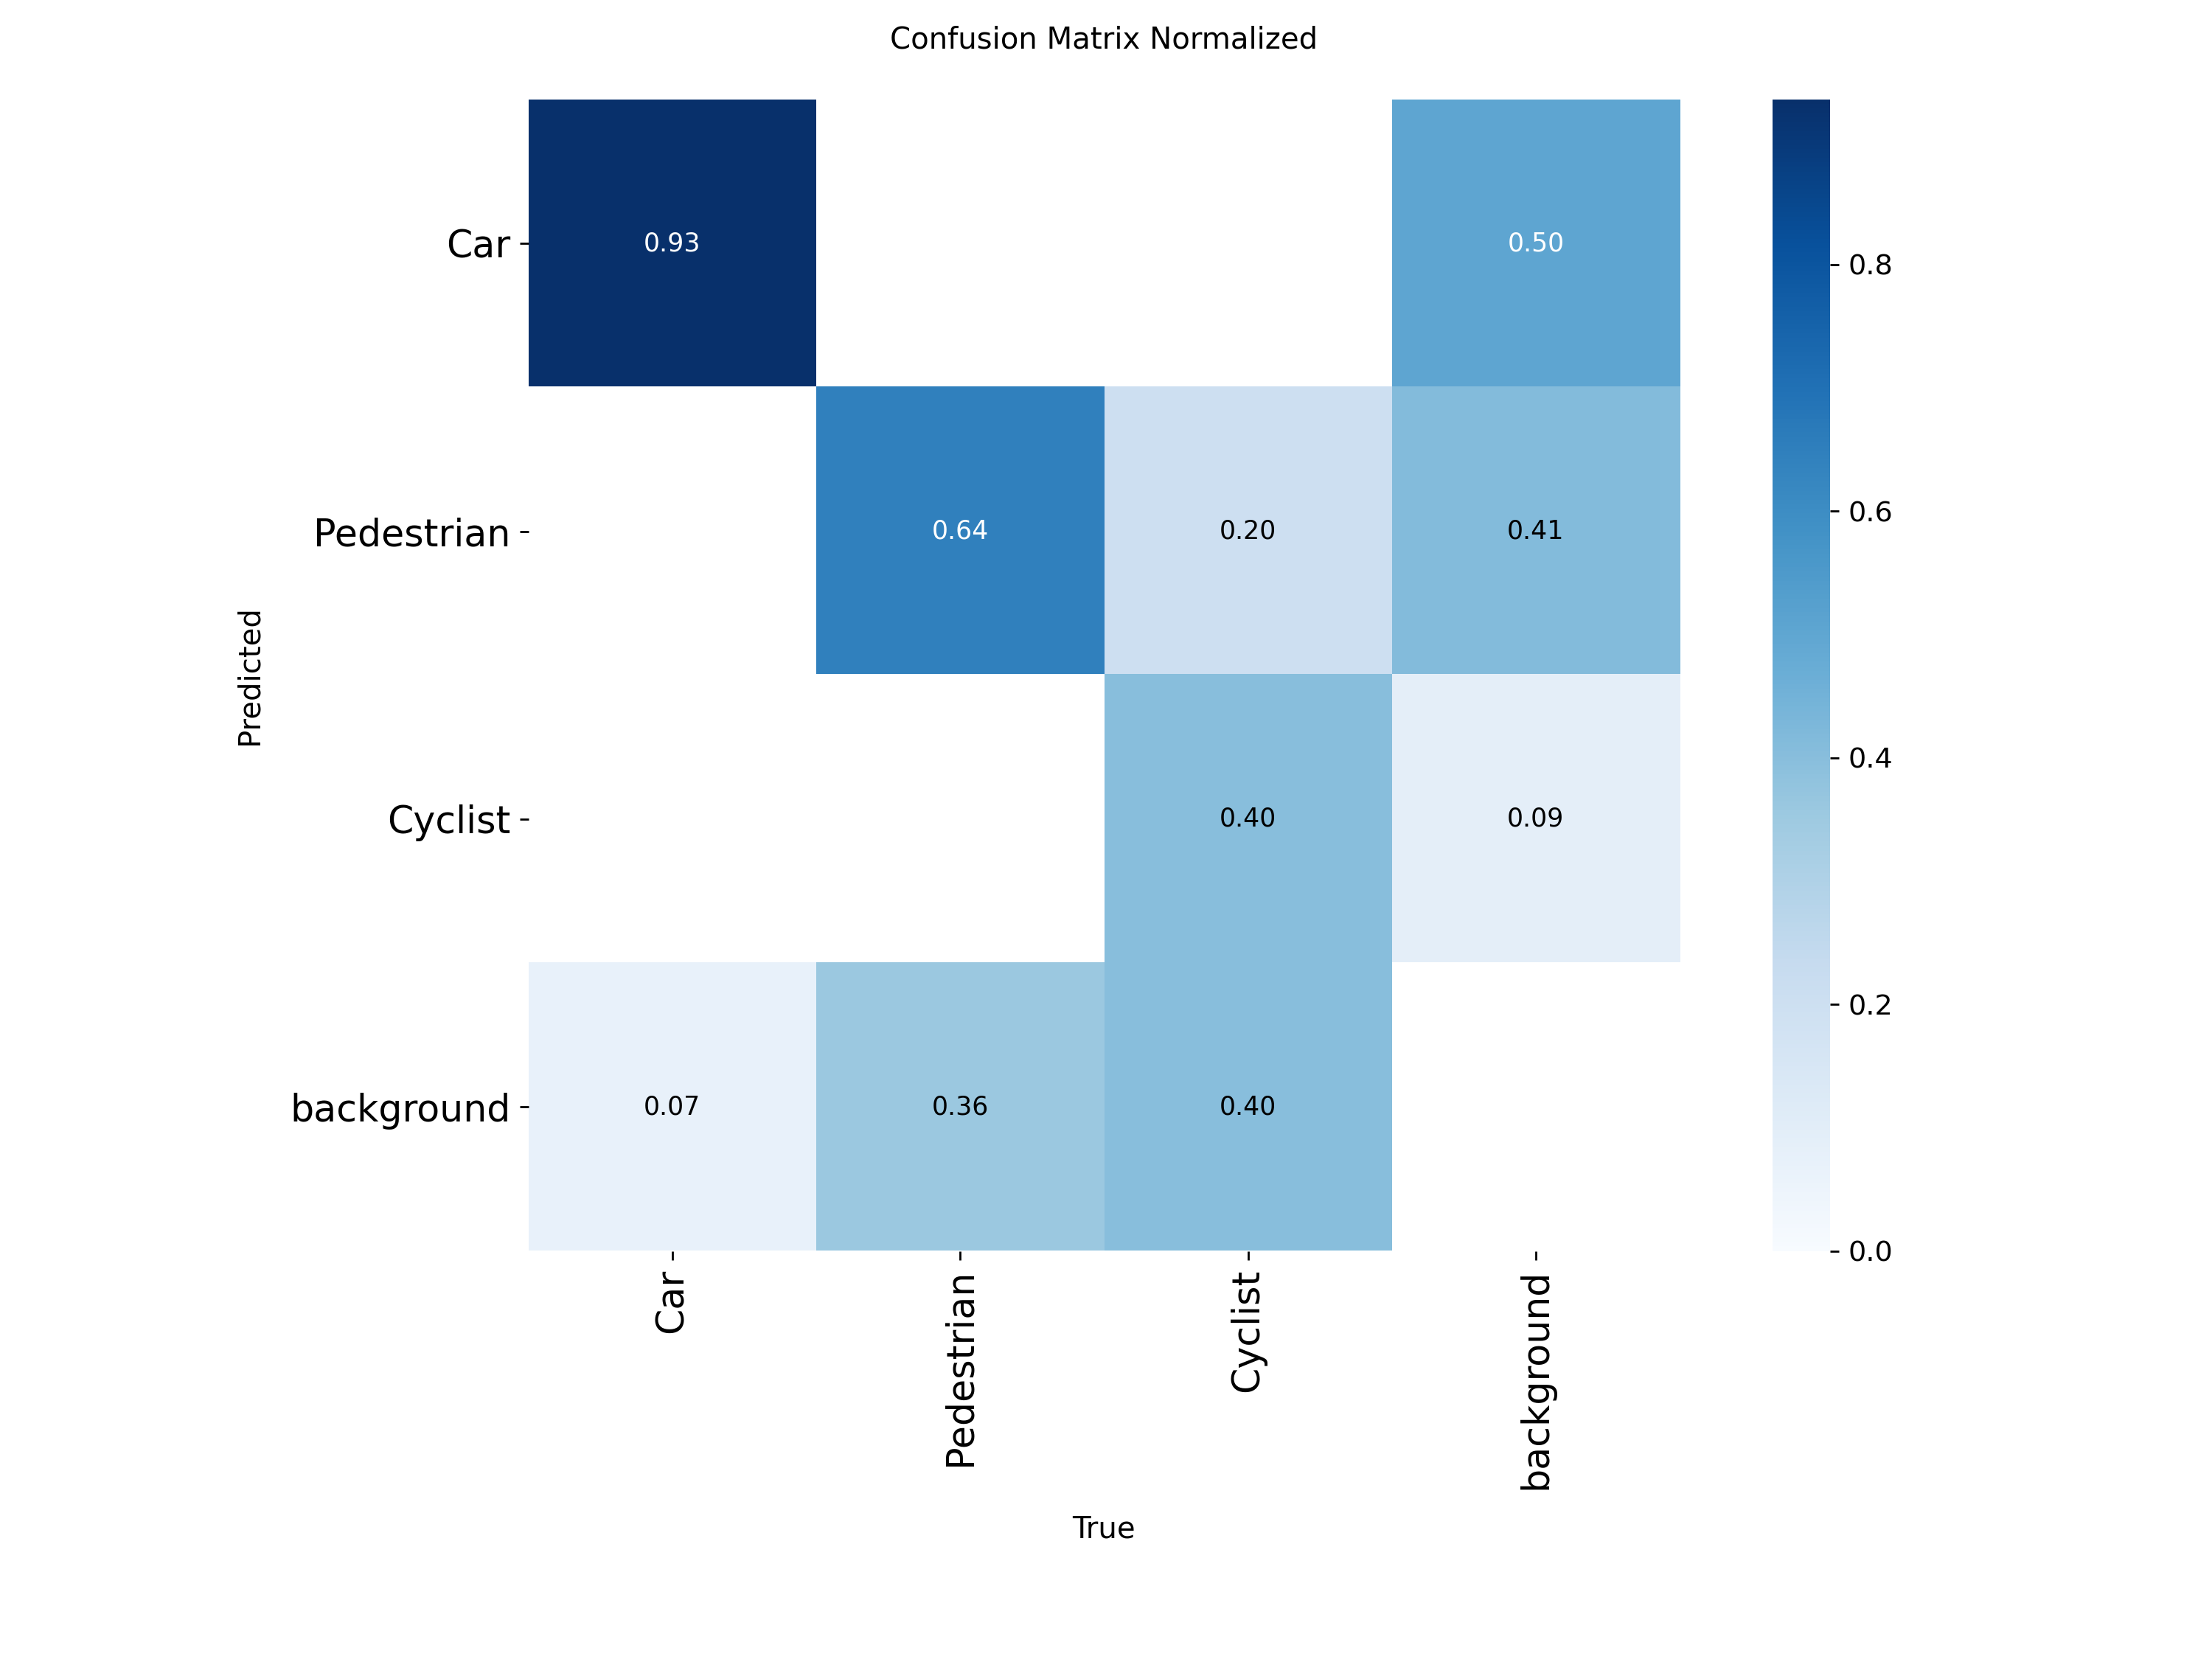

Confusion Matrix (raw counts)


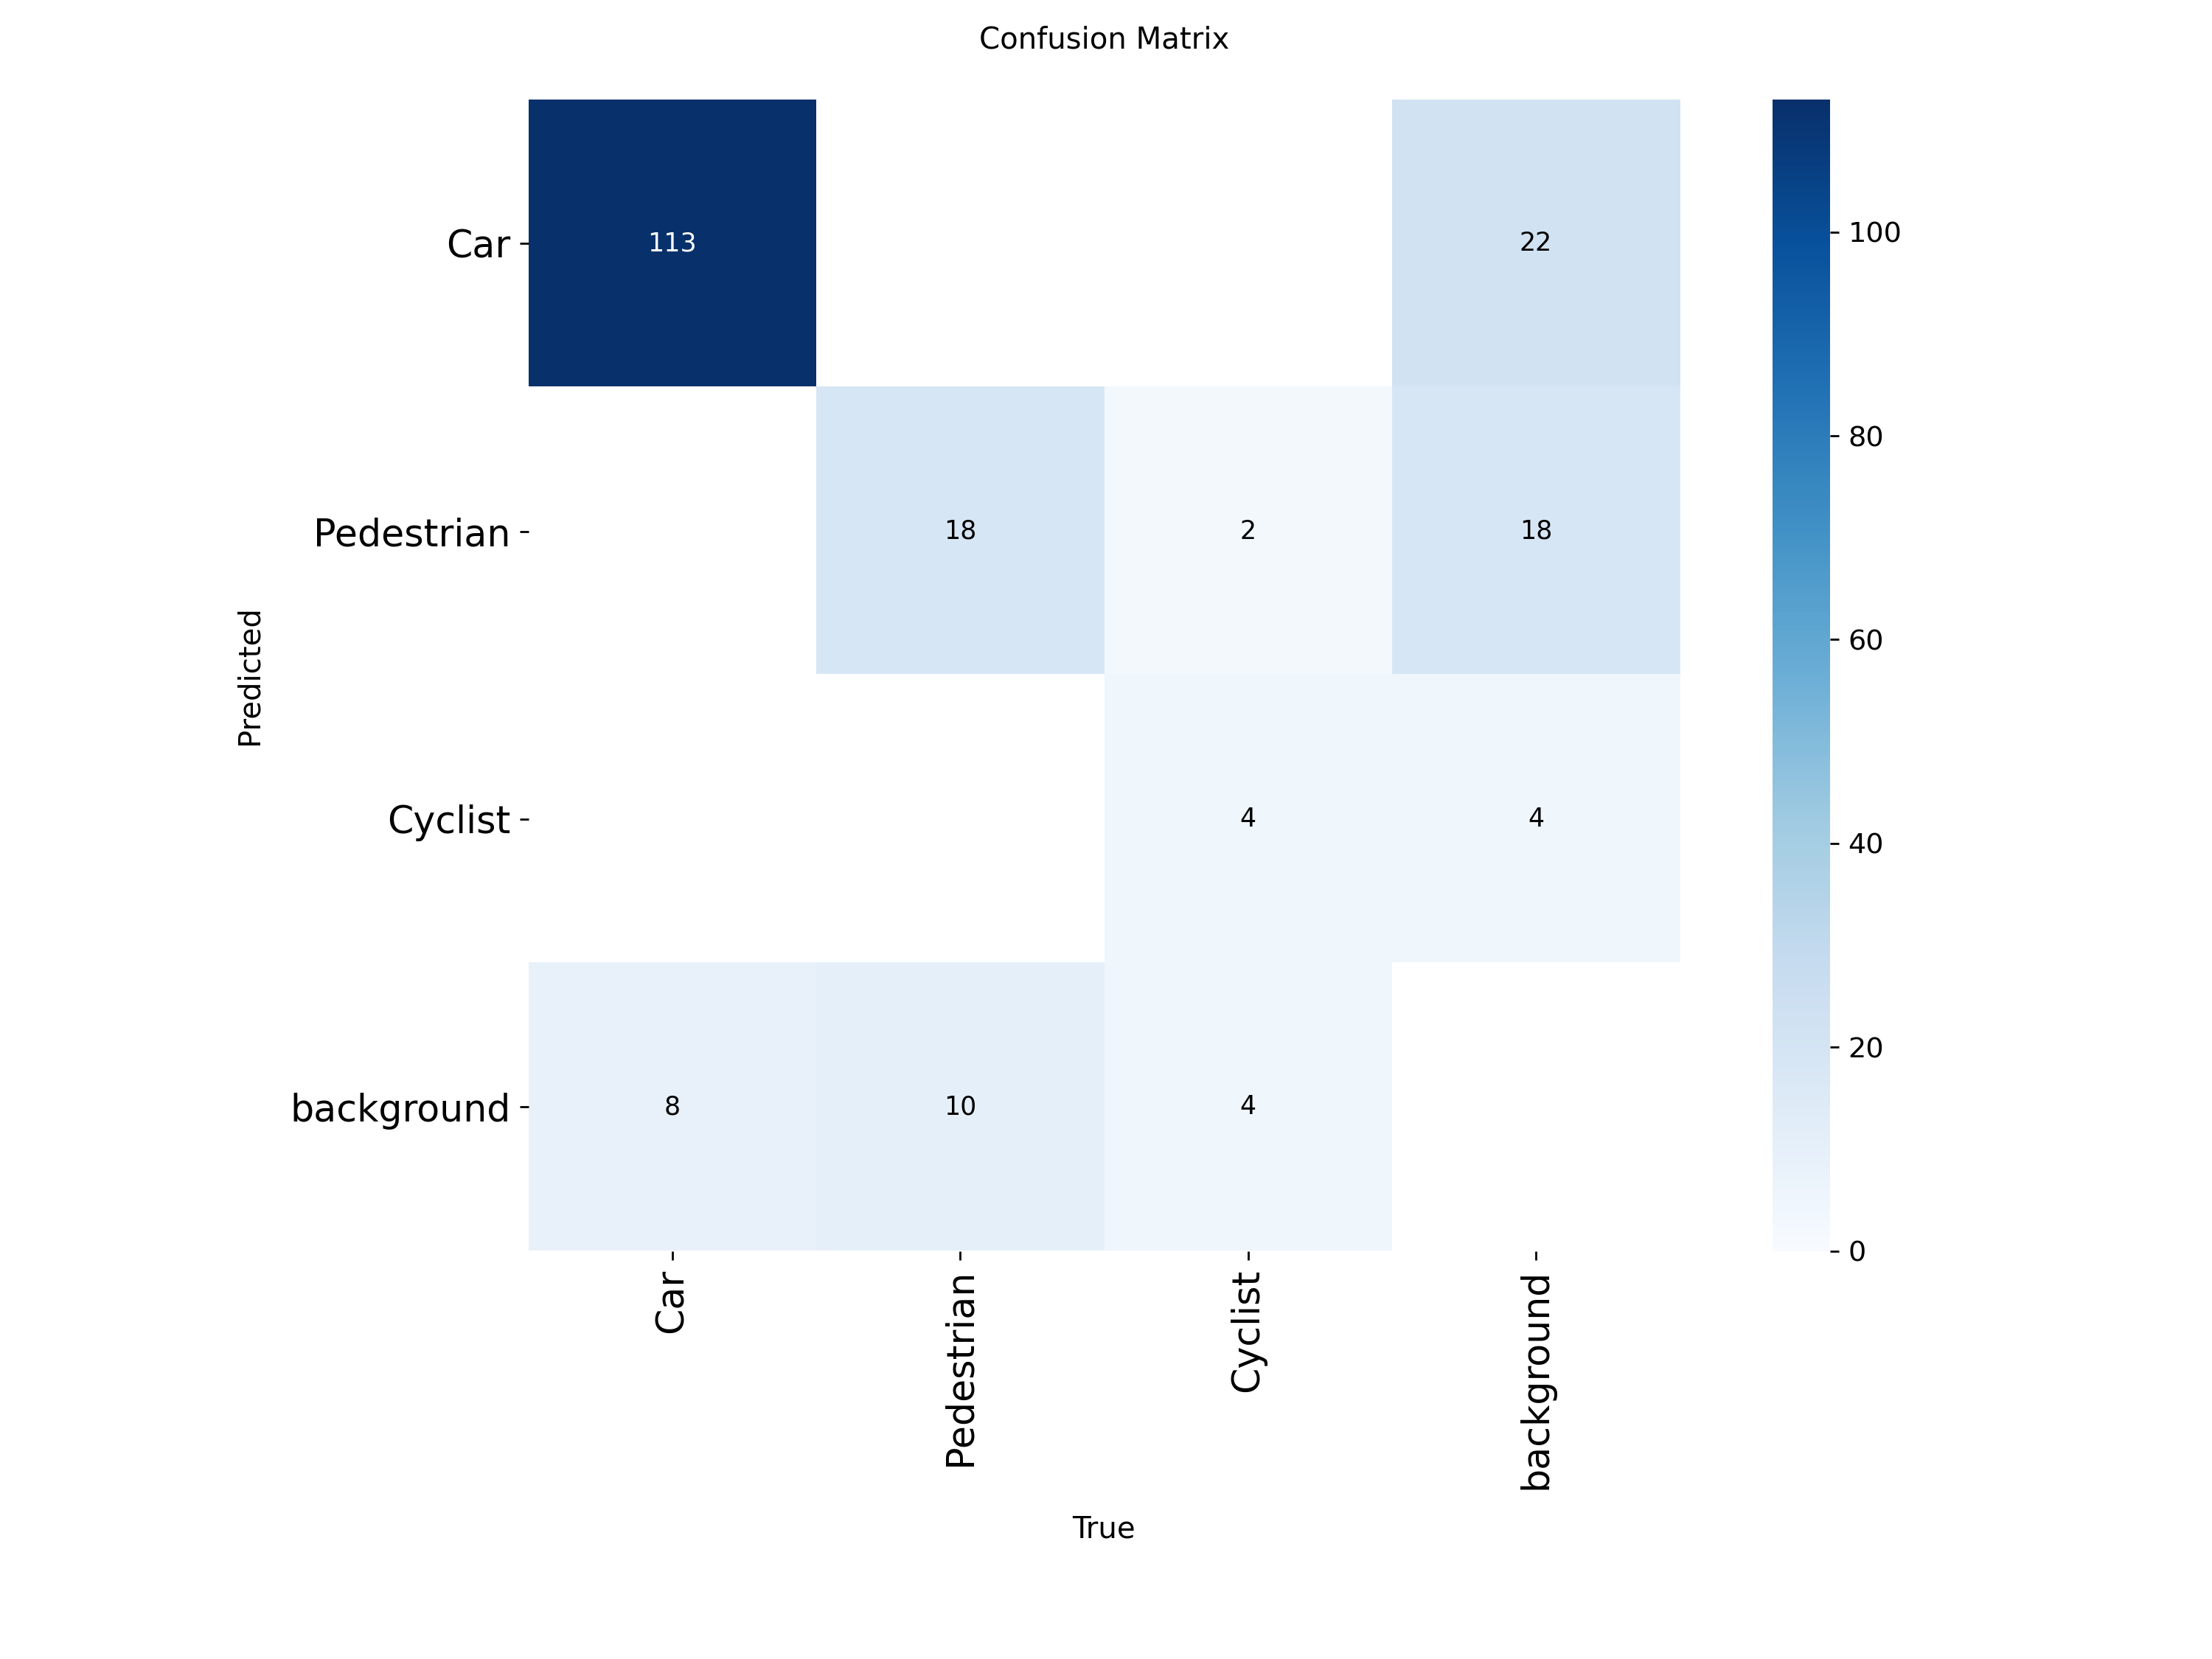

In [27]:
# ------ VISUALIZE CONFUSION MATRIX --------
#TO-DO: Add the code to visualize the confusion matrix
from IPython.display import Image, display

print("Confusion Matrix (normalized)")
display(Image('/content/runs/detect/val-8/confusion_matrix_normalized.png'))

print("Confusion Matrix (raw counts)")
display(Image('/content/runs/detect/val-8/confusion_matrix.png'))


0: 416x1280 3 Cars, 8.6ms
1: 416x1280 11 Cars, 8.6ms
2: 416x1280 10 Cars, 8.6ms
3: 416x1280 1 Car, 1 Pedestrian, 8.6ms
4: 416x1280 8 Cars, 8.6ms
5: 416x1280 9 Cars, 2 Pedestrians, 8.6ms
Speed: 3.1ms preprocess, 8.6ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 1280)


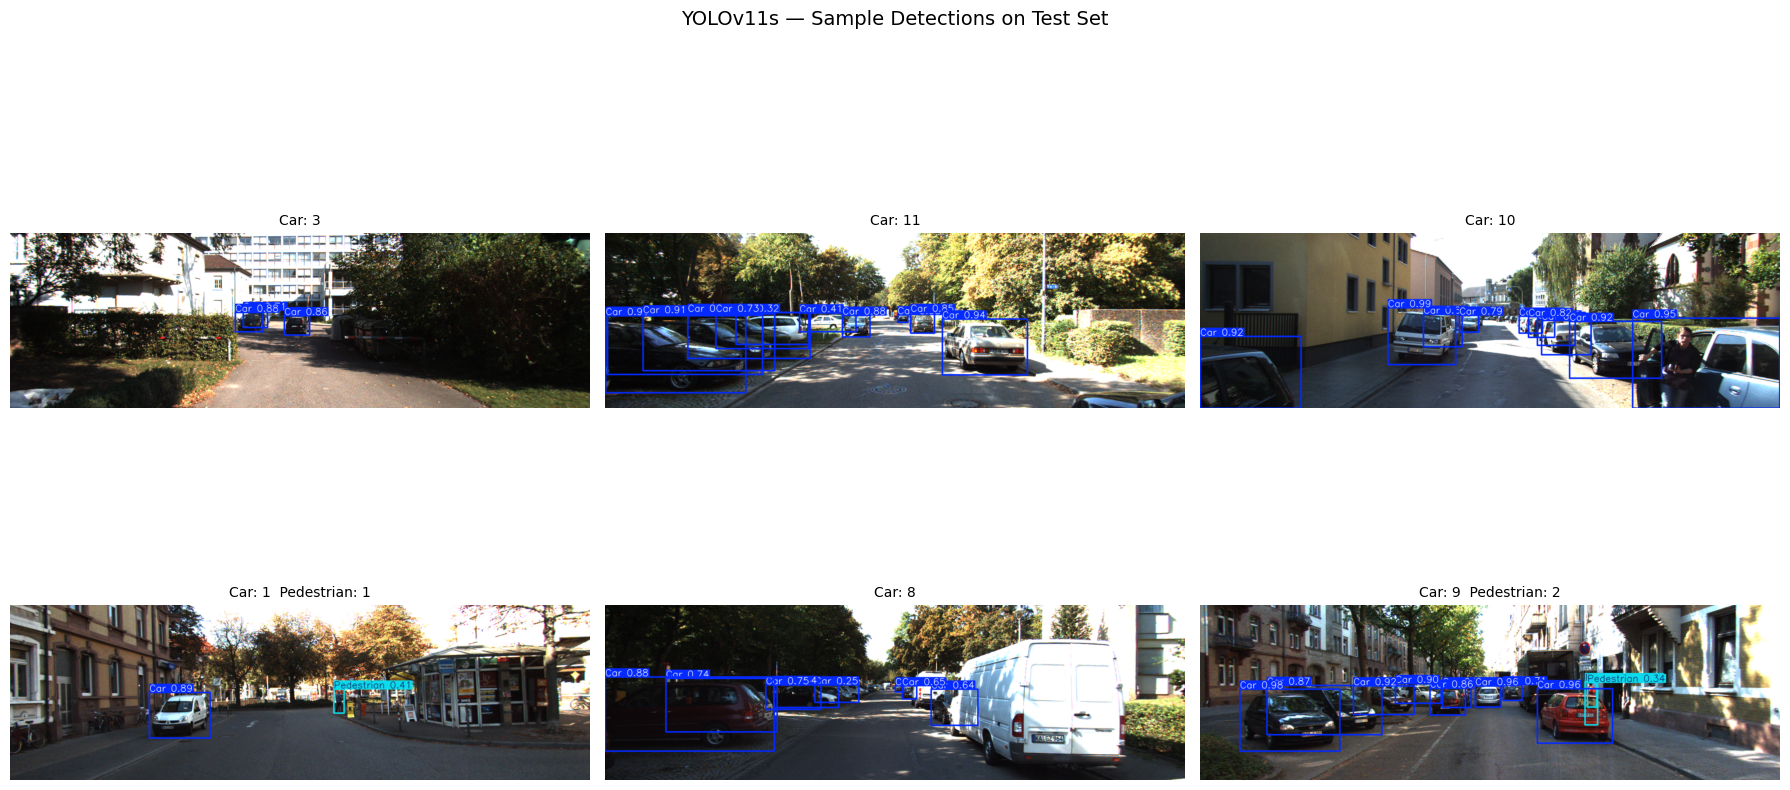

Saved to /content/runs/yolo11s_kitti_tuned/sample_detections.png


In [28]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
#TO-DO: Add the code to run inference and visualize the outputs results

# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

model = YOLO('/content/runs/yolo11s_kitti_tuned/weights/best.pt')

# pick 6 random test images
test_images = list(Path(TEST_IMG).glob('*.png'))
sample_images = random.sample(test_images, min(6, len(test_images)))

# run inference
results = model(sample_images, conf=0.25)

# plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv11s — Sample Detections on Test Set', fontsize=14)

for ax, result in zip(axes.flat, results):
    img = result.plot()           # draws boxes + labels onto the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

    # count detections per class
    if result.boxes is not None and len(result.boxes):
        class_ids = result.boxes.cls.int().tolist()
        names = [model.names[c] for c in class_ids]
        counts = {n: names.count(n) for n in set(names)}
        label = '  '.join(f"{k}: {v}" for k, v in counts.items())
    else:
        label = 'no detections'
    ax.set_title(label, fontsize=10)

plt.tight_layout()
plt.savefig('/content/runs/yolo11s_kitti_tuned/sample_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /content/runs/yolo11s_kitti_tuned/sample_detections.png")


## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars?

## Ans
The inference speed of the model is 8.6 ms, and total detection is 12.6 ms. The detection can therefore be performed with 79 fps (